# EfficientNet Binary Classification - Reduced Dataset

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import os

import json
import joblib

from torch.utils.data import DataLoader, Dataset
import torch.utils.data as utils
from torchvision import transforms

import torch
import torch.nn as nn
import torch.optim as optim 
import torchvision
from loguru import logger

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from efficientnet_pytorch import EfficientNet
from early_stopping_pytorch import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, roc_curve, auc



from nazi_symbols_classification.training.data_preparation import get_image_paths, load_labels_df
from nazi_symbols_classification.training.torch_dataset_preparation import ImageData, get_device, to_device, ToDeviceLoader
%matplotlib inline

## Data Preparation

Load the dataset and prepare it for training. The dataset is expected to be in a specific directory structure.
then we create PyTorch DataLoader objects for training, validation, and testing datasets.

In [3]:
dir_name = os.path.dirname(os.getcwd())
dataset_path = f"{dir_name}/datasets/nazi-symbols-detection-simple"

In [5]:
train_labels_df = load_labels_df(dataset_path, "train", binary=True)
valid_labels_df = load_labels_df(dataset_path, "val", binary=True)
test_labels_df = load_labels_df(dataset_path, "test", binary=True)

2025-06-10 02:44:25.011 | INFO     | __main__:load_labels_df:3 - Number of images in train is 77449
2025-06-10 02:44:25.046 | INFO     | __main__:load_labels_df:3 - Number of images in val is 15274
2025-06-10 02:44:25.064 | INFO     | __main__:load_labels_df:3 - Number of images in test is 14961


In [6]:
data_transf = transforms.Compose([transforms.ToPILImage(), 
                                  transforms.Grayscale(num_output_channels=3),
                                  transforms.Resize((224, 224)), 
                                  transforms.ToTensor(),
                                  transforms.Normalize((0.5,), (0.5,))])

def create_datasets(batch_size, dataset_path=dataset_path):
    train_data = ImageData(df = train_labels_df,
                           data_directory = os.path.join(dataset_path, 'train'),
                           transform = data_transf,
                           label_column="contained_nazi")
    train_loader = DataLoader(dataset = train_data, batch_size = batch_size, shuffle=True)
    
    valid_data = ImageData(df = valid_labels_df, 
                           data_directory = os.path.join(dataset_path, 'val'), 
                           transform = data_transf,
                           label_column="contained_nazi")
    valid_loader = DataLoader(dataset = valid_data, batch_size = batch_size, shuffle=False)

    test_data = ImageData(df = test_labels_df, 
                           data_directory = os.path.join(dataset_path, 'test'), 
                           transform = data_transf,
                           label_column="contained_nazi")
    test_loader = DataLoader(dataset = test_data, batch_size = batch_size, shuffle=False)
    return train_loader, valid_loader, test_loader

In [8]:
batch_size = 48

train_loader, test_loader, valid_loader = create_datasets(batch_size, dataset_path)

Device Preparation

In [ ]:
device = get_device()
print(device)

train_dl = ToDeviceLoader(train_loader, device)
valid_dl = ToDeviceLoader(valid_loader, device)
test_dl = ToDeviceLoader(test_loader, device)

### Data Sanity Check

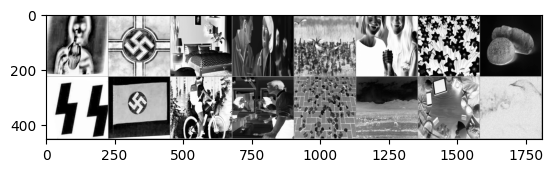

In [9]:
# Helper function for inline image display
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(train_loader)
images, labels = next(dataiter)

# Create a grid from the images and show them
img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)

## Model Preparation

In [10]:
model = EfficientNet.from_name('efficientnet-b2', num_classes=2)

Unfreezing model weights

In [11]:
for param in model.parameters():
    param.requires_grad = True

Changing the final layer to output a single value for binary classification

In [12]:
num_ftrs = model._fc.in_features
model._fc = nn.Linear(num_ftrs, 1)

In [2]:
model = model.to(device)

SyntaxError: invalid syntax (2980682540.py, line 1)

In [14]:
optimizer = optim.NAdam(model.parameters())

In [15]:
loss_fn = nn.BCELoss()

Define the training function

In [16]:
def train_model(model, patience, n_epochs):
    
    # to track the training loss as the model trains
    train_losses = []
    # to track the validation loss as the model trains
    valid_losses = []
    # to track the average training loss per epoch as the model trains
    avg_train_losses = []
    # to track the average validation loss per epoch as the model trains
    avg_valid_losses = [] 
    
    # initialize the early_stopping object
    early_stopping = EarlyStopping(patience=patience, verbose=True, path="efficientnet-output/efficientnet-b2-binary-pretrained-simple-size-224-batch-48.pt")
    
    for epoch in range(n_epochs):

        ###################
        # train the model #
        ###################
        model.train() # prep model for training
        for i, (data, target) in enumerate(train_dl):
            # Every data instance is an input + label pair
            target = target.float()                
            target = target.unsqueeze(1)
    
            # Zero your gradients for every batch!
            optimizer.zero_grad()
    
            # Make predictions for this batch
            output = model(data)
            m = nn.Sigmoid()
    
            # Compute the loss and its gradients
            loss = loss_fn(m(output), target)
            loss.backward()
    
            # Adjust learning weights
            optimizer.step()
            # record training loss
            train_losses.append(loss.item())

        ######################    
        # validate the model #
        ######################
        model.eval() # prep model for evaluation
        for data, target in valid_dl:
            target = target.float()                
            target = target.unsqueeze(1)
            # forward pass: compute predicted outputs by passing inputs to the model
            output = model(data)
            m = nn.Sigmoid()
            # calculate the loss
            loss = loss_fn(m(output), target)
            # record validation loss
            valid_losses.append(loss.item())

        # print training/validation statistics 
        # calculate average loss over an epoch
        train_loss = np.average(train_losses)
        valid_loss = np.average(valid_losses)
        avg_train_losses.append(train_loss)
        avg_valid_losses.append(valid_loss)
        
        epoch_len = len(str(n_epochs))
        
        print_msg = (f'[{(epoch + 1):>{epoch_len}}/{(n_epochs + 1):>{epoch_len}}] ' +
                     f'train_loss: {train_loss:.5f} ' +
                     f'valid_loss: {valid_loss:.5f}')
        
        print(print_msg)
        
        # clear lists to track next epoch
        train_losses = []
        valid_losses = []
        
        # early_stopping needs the validation loss to check if it has decresed, 
        # and if it has, it will make a checkpoint of the current model
        early_stopping(valid_loss, model)
        
        if early_stopping.early_stop:
            print("Early stopping")
            break
        
    # load the last checkpoint with the best model
    model.load_state_dict(torch.load('efficientnet-output/efficientnet-b2-binary-pretrained-simple-size-224-batch-48.pt', weights_only=True))

    return  model, avg_train_losses, avg_valid_losses

## Training the Model

In [17]:
%%time
# Training model for 5 epochs and logging the time required for the entire training process
# Initializing in a separate cell so we can easily add more epochs to the same run
n_epochs = 100

# early stopping patience; how long to wait after last time validation loss improved.
patience = 10

model, train_loss, valid_loss = train_model(model, patience, n_epochs)

[  1/101] train_loss: 0.18179 valid_loss: 0.05400
Validation loss decreased (inf --> 0.054003).  Saving model ...
[  2/101] train_loss: 0.10870 valid_loss: 0.04636
Validation loss decreased (0.054003 --> 0.046355).  Saving model ...
[  3/101] train_loss: 0.08570 valid_loss: 0.04145
Validation loss decreased (0.046355 --> 0.041448).  Saving model ...
[  4/101] train_loss: 0.07344 valid_loss: 0.03701
Validation loss decreased (0.041448 --> 0.037012).  Saving model ...
[  5/101] train_loss: 0.06454 valid_loss: 0.03394
Validation loss decreased (0.037012 --> 0.033939).  Saving model ...
[  6/101] train_loss: 0.05879 valid_loss: 0.03668
EarlyStopping counter: 1 out of 10
[  7/101] train_loss: 0.05218 valid_loss: 0.04419
EarlyStopping counter: 2 out of 10
[  8/101] train_loss: 0.04591 valid_loss: 0.03562
EarlyStopping counter: 3 out of 10
[  9/101] train_loss: 0.04402 valid_loss: 0.03976
EarlyStopping counter: 4 out of 10
[ 10/101] train_loss: 0.03862 valid_loss: 0.03149
Validation loss decr

In [33]:
history = dict(train_loss=train_loss, valid_loss=valid_loss)
with open('efficientnet-output/efficientnet-binary-pretrained-simple-history.json', 'w') as f:
    f.write(json.dumps(history))

## Evaluating the Model

In [37]:
model.load_state_dict(torch.load('efficientnet-output/efficientnet-b2-binary-pretrained-simple-size-224-batch-48.pt', weights_only=True))
model.eval()

EfficientNet(
  (_conv_stem): Conv2dStaticSamePadding(
    3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
    (static_padding): ZeroPad2d((0, 1, 0, 1))
  )
  (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
  (_blocks): ModuleList(
    (0): MBConvBlock(
      (_depthwise_conv): Conv2dStaticSamePadding(
        32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
        (static_padding): ZeroPad2d((1, 1, 1, 1))
      )
      (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
      (_se_reduce): Conv2dStaticSamePadding(
        32, 8, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_se_expand): Conv2dStaticSamePadding(
        8, 32, kernel_size=(1, 1), stride=(1, 1)
        (static_padding): Identity()
      )
      (_project_conv): Conv2dStaticSamePadding(
        32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False
    

### Evaluating on the Test Set

In [39]:
outputs = []
y_true = []
probabilities = []
out = None
for images, labels in test_dl:
    with torch.no_grad():
        output = model(images)
    pred = torch.sigmoid(output)
    predicted_vals = pred > 0.5
    y_true += to_device(labels, "cpu")
    outputs += to_device(predicted_vals, "cpu")
    probabilities += to_device(pred, "cpu")

Display classification report and Calculating the ROC AUC Score

In [40]:
outputs = [int(out) for out in outputs]

fpr, tpr, threshold = roc_curve(y_true, probabilities)
roc_auc = auc(fpr, tpr)
roc_auc_result = dict(fpr=fpr, tpr=tpr, threshold=threshold, roc_auc=roc_auc)

print(classification_report(y_true, outputs, digits=3))
print("accuracy score:", accuracy_score(y_true, outputs))
print("roc auc score:", roc_auc_score(y_true, outputs))

              precision    recall  f1-score   support

           0      0.995     0.993     0.994     14973
           1      0.667     0.744     0.703       301

    accuracy                          0.988     15274
   macro avg      0.831     0.868     0.848     15274
weighted avg      0.988     0.988     0.988     15274

accuracy score: 0.9876260311640697
roc auc score: 0.8683529578046686


In [25]:
joblib.dump(roc_auc_result, 'efficientnet-output/efficientnet-binary-pretrained-simple-roc-auc-results.joblib')

['efficientnet-binary-pretrained-roc-auc-results.joblib']